这个文档是复刻邱晔学姐的单云模型拟合代码，文章参考的是  
《Three-dimensional Velocity Fields of the Solar Filament Eruptions Detected by CHASE》  
对应的程序文件是《single_cloud_model_for_both.pro》

In [1]:
import sunpy
import sunpy.map
import numpy as np
from math import *
import astropy.units as u
from astropy.io import fits
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from sunpy.coordinates import frames
import matplotlib.gridspec as gridspec
from scipy.interpolate import interp1d,RegularGridInterpolator
from astropy.coordinates import SkyCoord
from matplotlib.patches import ConnectionPatch
import os,cv2
from scipy.optimize import fmin
from scipy.ndimage import affine_transform
import shutil
from scipy.io import readsav
import glob
from matplotlib.patches import Rectangle
from scipy.ndimage import zoom
from matplotlib.colors import Normalize,LogNorm
import matplotlib.ticker as ticker
from scipy.ndimage import gaussian_filter1d
from sunpy.coordinates import Helioprojective, SphericalScreen, propagate_with_solar_surface
from astropy.wcs import WCS
from gaussian_fit import fit_gaussian, fit_double_gaussian
import matplotlib.ticker as ticker
from matplotlib.path import Path

In [9]:
#数据准备
dir=r'C:\Learning\PHD1st\magnetic_reconnecion\data\CHASE_Ha\RSM20240618T211711_0000_HA.fits'
rsm=fits.open(dir)
left_index=30
right_index=108
lam00 = rsm[1].header['CRVAL3'] + np.arange(rsm[1].header['NAXIS3']) * rsm[1].header['CDELT3']
lam=lam00[left_index:right_index]#±1.5A
print(lam00[30],lam00[44],lam00[54],lam00[96],lam00[108])

6560.8692420172665 6561.5480186241975 6562.032859057719 6564.069188878513 6564.6509973987395


第一个单元格：读取数据，计算共同参考线心

波长范围：6560.869242–6564.602513 Å，共 78 点
矩方法背景线心：6562.85235648 Å
固定误差：22.42 DN；名义自由度：73


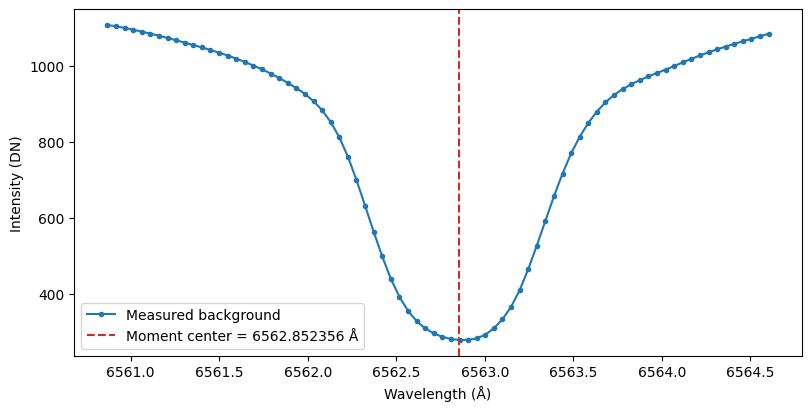

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
from pathlib import Path
from datetime import datetime
from scipy.optimize import least_squares

data_cube = np.asarray(rsm[1].data[left_index:right_index, 789:806, 1515:1526], dtype=float)
wave = np.asarray(lam00[left_index:right_index], dtype=float)
I0 = np.asarray(rsm[1].data[left_index:right_index, 797:826, 1540:1569], dtype=float).mean(axis=(1, 2))

sigma = 22.42
c = 3e5  # km/s，与学姐代码一致
y_start, x_start = 789, 1515
param_names = np.array(["S", "tau0", "v", "W", "a"])
n_params = len(param_names)
n_wave, ny, nx = data_cube.shape
x_pixels = np.arange(x_start, x_start + nx)
y_pixels = np.arange(y_start, y_start + ny)

# if data_cube.shape != (52, 17, 11) or wave.shape != (52,) or I0.shape != (52,):
#     raise ValueError("请检查输入形状，应为 data_cube=(52,17,11)，wave/I0=(52,)。")
if not np.all(np.isfinite(wave)) or not np.all(np.isfinite(I0)):
    raise ValueError("背景或波长存在无效值，请先检查。")
if not np.all(np.diff(wave) > 0) or not np.allclose(np.diff(wave), np.diff(wave)[0], rtol=1e-4, atol=1e-10):
    raise ValueError("这段矩方法代码要求波长递增且近似等间隔。")
if np.max(I0) <= 0 or np.ptp(I0) == 0:
    raise ValueError("背景光谱没有可用的吸收线变化。")

# 使用全部 52 点计算吸收深度的一阶矩。
background_depth = 1.01 * np.max(I0) - I0
wave_anchor = np.mean(wave)
lam0 = wave_anchor + np.sum((wave - wave_anchor) * background_depth) / np.sum(background_depth)

print(f"波长范围：{wave[0]:.6f}–{wave[-1]:.6f} Å，共 {n_wave} 点")
print(f"矩方法背景线心：{lam0:.8f} Å")
print(f"固定误差：{sigma} DN；名义自由度：{n_wave - n_params}")

fig, ax = plt.subplots(figsize=(8, 4), constrained_layout=True)
ax.plot(wave, I0, "o-", ms=3, label="Measured background")
ax.axvline(lam0, color="tab:red", ls="--", label=f"Moment center = {lam0:.6f} Å")
ax.set(xlabel="Wavelength (Å)", ylabel="Intensity (DN)")
ax.legend()
plt.show()

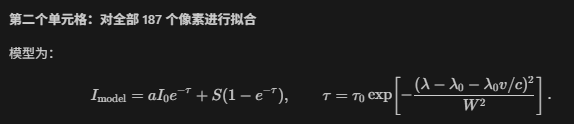

In [12]:
# p 的顺序：[S, tau0, v, W(Å), a]。
optical_depth = lambda p, wl: p[1] * np.exp(-((wl - lam0 - lam0 * p[2] / c) / p[3])**2)
cloud_model = lambda p, wl, bg: p[4] * bg * np.exp(-optical_depth(p, wl)) + p[0] * (-np.expm1(-optical_depth(p, wl)))

params = np.full((ny, nx, n_params), np.nan)
parameter_errors = np.full_like(params, np.nan)
model_cube = np.full_like(data_cube, np.nan)
vtest_map = np.full((ny, nx), np.nan)
raw_sse = np.full((ny, nx), np.nan)
chi2 = np.full((ny, nx), np.nan)
reduced_chi2 = np.full((ny, nx), np.nan)
n_valid = np.zeros((ny, nx), dtype=int)
dof = np.full((ny, nx), -n_params, dtype=int)
success = np.zeros((ny, nx), dtype=bool)
physical = np.zeros((ny, nx), dtype=bool)
source_at_lower_bound = np.zeros((ny, nx), dtype=bool)
fit_details = {}

for j, i in np.ndindex(ny, nx):
    y, x = y_start + j, x_start + i
    sp = data_cube[:, j, i]
    valid = np.isfinite(sp)
    n_valid[j, i] = valid.sum()
    dof[j, i] = n_valid[j, i] - n_params

    if dof[j, i] <= 0 or np.max(sp[valid]) <= 0 or np.ptp(sp[valid]) == 0:
        fit_details[(y, x)] = {"error": "有效光谱点不足或光谱没有可用变化"}
        continue

    wl, obs, bg = wave[valid], sp[valid], I0[valid]

    # 目标谱线的矩位置只用于提供速度初值，最终速度仍参与优化。
    depth = 1.01 * np.max(obs) - obs
    line_center = wave_anchor + np.sum((wl - wave_anchor) * depth) / np.sum(depth)
    vtest = (line_center - lam0) / lam0 * c
    vtest_map[j, i] = vtest

    # 沿用学姐的初值形式与边界；W 下限用极小正数避免除零。
    start = np.array([np.clip(np.min(obs), 0, np.max(obs)), 1.0, vtest, 0.3, 1.0])
    lower = np.array([0.0, -np.inf, -np.inf, 1e-6, -np.inf])
    upper = np.array([np.max(obs), np.inf, np.inf, np.inf, np.inf])
    residual = lambda p: (cloud_model(p, wl, bg) - obs) / sigma

    try:
        with np.errstate(over="raise", invalid="raise", divide="raise"):
            fit = least_squares(residual, start, bounds=(lower, upper), method="trf", jac="3-point", x_scale="jac", loss="linear", max_nfev=3000, ftol=1e-8, xtol=1e-8, gtol=1e-8)
            fitted = cloud_model(fit.x, wave, I0)

        params[j, i] = fit.x
        model_cube[:, j, i] = fitted
        raw_sse[j, i] = np.sum((fitted[valid] - obs)**2)
        chi2[j, i] = raw_sse[j, i] / sigma**2
        reduced_chi2[j, i] = chi2[j, i] / dof[j, i]
        success[j, i] = fit.success
        physical[j, i] = fit.x[1] > 0 and fit.x[3] > 0 and fit.x[4] > 0
        source_at_lower_bound[j, i] = fit.x[0] <= 1e-6 * max(np.max(obs), 1.0)
        fit_details[(y, x)] = fit

    except (ValueError, RuntimeError, FloatingPointError) as exc:
        fit_details[(y, x)] = {"error": str(exc)}
        print(f"y={y}, x={x} 拟合异常：{exc}")
        continue

    # 局部线性近似下的形式参数误差，不用约化卡方再次缩放。
    # 未收敛、碰边界或雅可比矩阵秩不足时保留 NaN。
    if fit.success and not np.any(fit.active_mask) and not source_at_lower_bound[j, i]:
        try:
            _, singular_values, vt = np.linalg.svd(fit.jac, full_matrices=False)
            tolerance = np.finfo(float).eps * max(fit.jac.shape) * singular_values[0]
            if np.all(singular_values > tolerance):
                covariance = (vt.T / singular_values**2) @ vt
                parameter_errors[j, i] = np.sqrt(np.maximum(np.diag(covariance), 0))
        except np.linalg.LinAlgError:
            pass

    done = j * nx + i + 1
    if done % 10 == 0 or done == ny * nx:
        print(f"[{done}/{ny * nx}] y={y}, x={x}, v={fit.x[2]:.3f} km/s, a={fit.x[4]:.3f}, reduced chi2={reduced_chi2[j, i]:.4g}")

result = dict(params=params, param_names=param_names, parameter_errors=parameter_errors, S=params[..., 0], tau0=params[..., 1], v=params[..., 2], W_angstrom=params[..., 3], a=params[..., 4], model=model_cube, data_cube=data_cube, wavelength=wave, I0=I0, lam0=lam0, sigma=sigma, c_km_s=c, raw_sse=raw_sse, chi2=chi2, reduced_chi2=reduced_chi2, n_valid=n_valid, dof=dof, success=success, physical=physical, source_at_lower_bound=source_at_lower_bound, vtest=vtest_map, x_pixels=x_pixels, y_pixels=y_pixels, fit_details=fit_details, reference_method="first moment; depth=1.01*max(I)-I; all input wavelengths", optimizer="scipy least_squares trf; one initial guess")

print(f"优化收敛：{success.sum()}/{ny * nx}")
print(f"收敛且 tau0、W、a 为正：{np.count_nonzero(success & physical)}/{ny * nx}")

[10/187] y=789, x=1524, v=9.782 km/s, a=0.987, reduced chi2=0.2319
[20/187] y=790, x=1523, v=11.112 km/s, a=0.943, reduced chi2=0.5888
[30/187] y=791, x=1522, v=16.080 km/s, a=0.877, reduced chi2=1.914
[40/187] y=792, x=1521, v=-193.487 km/s, a=0.735, reduced chi2=2.351
[50/187] y=793, x=1520, v=11.636 km/s, a=0.903, reduced chi2=1.203
[60/187] y=794, x=1519, v=-9.949 km/s, a=0.945, reduced chi2=0.5104
[70/187] y=795, x=1518, v=-14.971 km/s, a=0.945, reduced chi2=0.2254
[80/187] y=796, x=1517, v=-7.869 km/s, a=0.944, reduced chi2=0.3319
[90/187] y=797, x=1516, v=-0.909 km/s, a=0.969, reduced chi2=0.3128
[100/187] y=798, x=1515, v=1.542 km/s, a=0.983, reduced chi2=0.1194
[110/187] y=798, x=1525, v=8.360 km/s, a=0.984, reduced chi2=0.4351
[120/187] y=799, x=1524, v=7.280 km/s, a=0.955, reduced chi2=0.873
[130/187] y=800, x=1523, v=-5.965 km/s, a=0.908, reduced chi2=0.3992
[140/187] y=801, x=1522, v=229.709 km/s, a=0.857, reduced chi2=10.62
[150/187] y=802, x=1521, v=-35.199 km/s, a=0.946

第三个单元格：保存完整结果和逐像素拟合图  
代码会创建独立目录，保存 result.pkl、汇总数据，以及每个像素的 .npz 和 .png

In [13]:
output_root = Path(r"C:\Learning\PHD1st\magnetic_reconnecion\data\CHASE_Ha_image\single_cloud_with_a")
run_dir = output_root / datetime.now().strftime("run_%Y%m%d_%H%M%S_%f")
pixel_dir = run_dir / "pixel_fits"
pixel_dir.mkdir(parents=True, exist_ok=False)

result["output_dir"] = run_dir
with open(run_dir / "result.pkl", "wb") as f:
    pickle.dump(result, f, protocol=pickle.HIGHEST_PROTOCOL)

np.savez_compressed(run_dir / "input_spectra.npz", data_cube=data_cube, wavelength=wave, I0=I0)
np.savez_compressed(run_dir / "fit_maps.npz", **{k: v for k, v in result.items() if k not in ("fit_details", "output_dir", "data_cube")})

for j, i in np.ndindex(ny, nx):
    y, x = y_start + j, x_start + i
    stem = pixel_dir / f"fit_y{y:04d}_x{x:04d}"
    sp = data_cube[:, j, i]
    fitted = model_cube[:, j, i]

    np.savez_compressed(stem.with_suffix(".npz"), wavelength=wave, intensity=sp, I0=I0, model=fitted, params=params[j, i], param_names=param_names, parameter_errors=parameter_errors[j, i], raw_sse=raw_sse[j, i], chi2=chi2[j, i], reduced_chi2=reduced_chi2[j, i], n_valid=n_valid[j, i], dof=dof[j, i], success=success[j, i], physical=physical[j, i], source_at_lower_bound=source_at_lower_bound[j, i], vtest=vtest_map[j, i], lam0=lam0, sigma=sigma, y=y, x=x)

    fig, axes = plt.subplots(2, 1, figsize=(7, 5), sharex=True, gridspec_kw={"height_ratios": [3, 1]}, constrained_layout=True)
    axes[0].errorbar(wave, sp, yerr=sigma, fmt=".", ms=4, elinewidth=0.6, label="Observed")
    axes[0].plot(wave, I0, color="green", label="Measured I0")

    if np.all(np.isfinite(params[j, i])):
        axes[0].plot(wave, params[j, i, 4] * I0, "--", color="gray", label="a × I0")
        axes[0].plot(wave, fitted, color="tab:orange", label="Single-cloud fit")
        axes[1].plot(wave, (sp - fitted) / sigma, ".-", ms=3)

    axes[0].axvline(lam0, ls="--", color="black", lw=0.8)
    axes[0].set(ylabel="Intensity (DN)", title=f"y={y}, x={x}; v={params[j, i, 2]:.2f} km/s; a={params[j, i, 4]:.3f}\nReduced chi2={reduced_chi2[j, i]:.4g}; converged={success[j, i]}")
    axes[0].legend(fontsize=8)
    axes[1].axhline(0, color="black", lw=0.8)
    axes[1].set(xlabel="Wavelength (Å)", ylabel="Residual / σ")
    fig.savefig(stem.with_suffix(".png"), dpi=150)
    plt.close(fig)

print(f"已保存：{run_dir}")

已保存：C:\Learning\PHD1st\magnetic_reconnecion\data\CHASE_Ha_image\single_cloud_with_a\run_20260915_155223_475338


In [ ]:
# with open(run_dir / "result.pkl", "rb") as f:
#     result = pickle.load(f)

# v_map = result["v"]
# a_map = result["a"]
# chi2_red_map = result["reduced_chi2"]

全部可计算像素：min=0.02646, median=0.4207, max=10.62


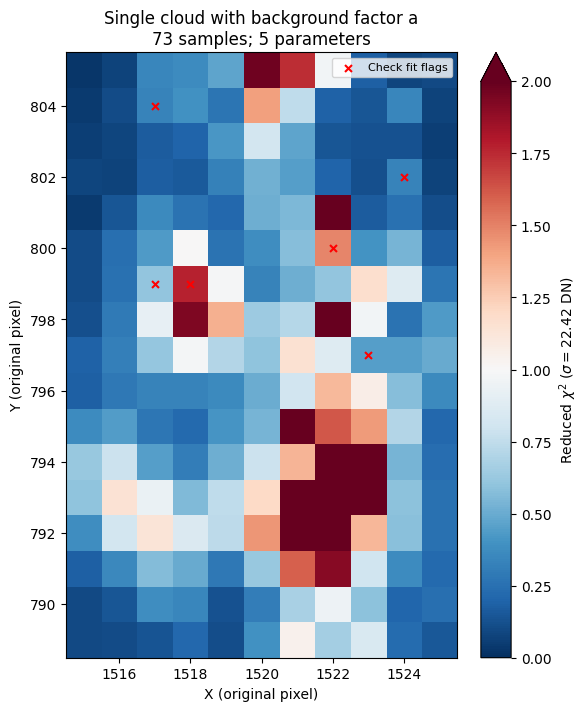

In [16]:
ha_image = np.nanmean(data_cube[:10], axis=0)
chi2_vmax = 2.0  # 色标上限；设为 None 则自动确定
extent = (1514.5, 1525.5, 788.5, 805.5)
cmap = plt.get_cmap("RdBu_r").copy()
cmap.set_bad("lightgray")
values = reduced_chi2[np.isfinite(reduced_chi2)]
if values.size:
    print(f"全部可计算像素：min={values.min():.4g}, median={np.median(values):.4g}, max={values.max():.4g}")
fig, ax = plt.subplots(figsize=(6, 7), constrained_layout=True)
im = ax.imshow(np.ma.masked_invalid(reduced_chi2), origin="lower", extent=extent, 
               cmap=cmap, interpolation="nearest", vmin=0, vmax=chi2_vmax)
if np.nanmin(ha_image) < 800 < np.nanmax(ha_image):
    ax.contour(x_pixels, y_pixels, ha_image, levels=[800], colors="white", linewidths=0.8)

marked = np.isfinite(reduced_chi2) & (~success | ~physical | source_at_lower_bound)
jy, ix = np.where(marked)
if jy.size:
    ax.scatter(x_pixels[ix], y_pixels[jy], marker="x", c="red", s=25, label="Check fit flags")
    ax.legend(fontsize=8)

extend = "max" if chi2_vmax is not None and np.any(reduced_chi2 > chi2_vmax) else "neither"
fig.colorbar(im, ax=ax, label=r"Reduced $\chi^2$ ($\sigma=22.42$ DN)", extend=extend)
ax.set(xlabel="X (original pixel)", ylabel="Y (original pixel)", 
       title=f"Single cloud with background factor a\n{right_index - left_index-5} samples; 5 parameters")
fig.savefig(run_dir / "reduced_chi2_map.png", dpi=300, bbox_inches="tight")
plt.show()




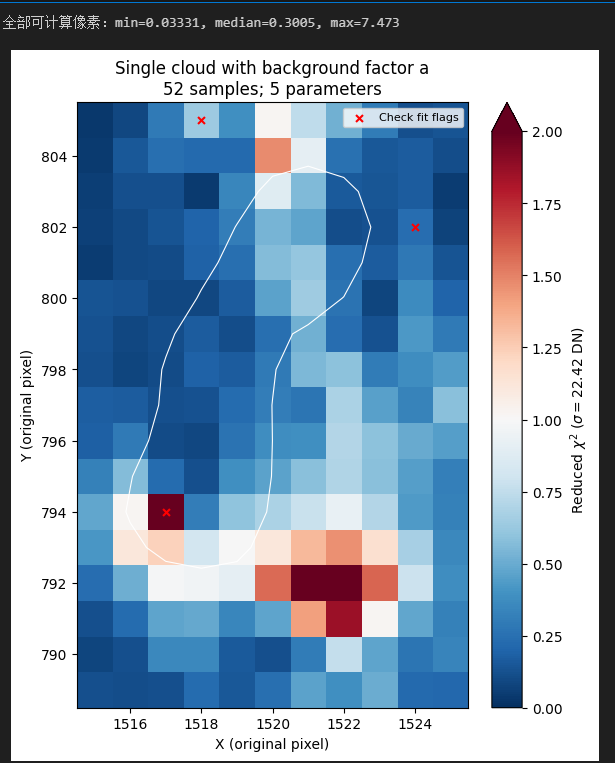